# 07 — Long-Only Out-of-Sample Validation (2019–2024)

## Purpose

Evaluate the locked strategies on the **true holdout** (2019-01 to 2024-09)
that was never used for any selection decision.

| Strategy | Factor | PC | Selected In |
|----------|--------|----|-------------|
| **(a)** All6-EW + TO\_MVO | All6-EW (NB05, 2009-2013) | TO\_MVO (NB06, 2014-2018) | Winner |
| **(b)** All6-EW + Momentum | All6-EW (NB05, 2009-2013) | Momentum (NB06, 2014-2018) | Runner-up |

Benchmarks: **EEM** (iShares MSCI EM ETF, total return) and **MSCI EM** (price index).

Transaction costs: **45bps** country-weighted realistic estimate (Domowitz et al. 2001).

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())

# ── Load EEM (primary, total-return) ──
eem_raw = pd.read_csv('../data/eem_returns_monthly.csv', index_col=0, parse_dates=True)
eem_raw['mret'] = pd.to_numeric(eem_raw['mret'], errors='coerce')
eem_raw = eem_raw.dropna(subset=['mret'])
eem_raw.index = eem_raw.index.to_period('M').to_timestamp()
eem_ret = eem_raw['mret'].sort_index()
eem_ret = eem_ret[~eem_ret.index.duplicated(keep='last')]

# ── Load MSCI EM (secondary, price-only) ──
msci_price = pd.read_excel('../data/msci_em_index_price.xlsx', index_col=0, parse_dates=True)
msci_price = msci_price.dropna().sort_index()
msci_ret_raw = msci_price.iloc[:, 0].pct_change(fill_method=None).dropna()
msci_ret_raw.index = msci_ret_raw.index.to_period('M').to_timestamp()
msci_ret = msci_ret_raw.sort_index()
msci_ret = msci_ret[~msci_ret.index.duplicated(keep='last')]

# ── Load strategy returns ──
pc_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_all_portfolio_returns.csv',
                      index_col=0, parse_dates=True)
COL_A = 'TO_MVO_All6EW_LW_60m'     # Strategy A
COL_B = 'Momentum_All6EW_LW_60m'   # Strategy B

# ── Turnover ──
stock_to_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
stock_to = stock_to_df.loc['All6-EW', 'avg_monthly_turnover']
mc_scores = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
pc_to = {}
for _, row in mc_scores.iterrows():
    if 'All6EW' in row['Strategy']:
        pc_to[row['PC']] = row['PC_TO']

TO_A = stock_to + pc_to.get('TO_MVO', 0.007)
TO_B = stock_to + pc_to.get('Momentum', 0.096)
TC_A = TO_A * (REALISTIC_TC_BPS / 10_000)
TC_B = TO_B * (REALISTIC_TC_BPS / 10_000)

STRATS = {
    '(a) All6-EW + TO_MVO':    {'col': COL_A, 'tc': TC_A, 'to': TO_A},
    '(b) All6-EW + Momentum':  {'col': COL_B, 'tc': TC_B, 'to': TO_B},
}

# ── Align to EEM common dates ──
common_eem = pc_ret.index.intersection(eem_ret.index)
holdout_eem = sorted([d for d in common_eem if d >= HOLD_START])

print(f'EEM coverage: {eem_ret.index[0].strftime("%Y-%m")} to {eem_ret.index[-1].strftime("%Y-%m")} ({len(eem_ret)} months, total-return)')
print(f'MSCI coverage: {msci_ret.index[0].strftime("%Y-%m")} to {msci_ret.index[-1].strftime("%Y-%m")} ({len(msci_ret)} months, price-only)')
print(f'Holdout (EEM): {len(holdout_eem)} months ({holdout_eem[0].strftime("%Y-%m")} to {holdout_eem[-1].strftime("%Y-%m")})')
print(f'Turnover: TO_MVO={TO_A:.3f}, Momentum={TO_B:.3f}')
print(f'TC drag @{REALISTIC_TC_BPS:.0f}bp: TO_MVO={TC_A*12:.2%}/yr, Momentum={TC_B*12:.2%}/yr')

EEM coverage: 2003-05 to 2024-09 (257 months, total-return)
MSCI coverage: 2001-05 to 2025-05 (289 months, price-only)
Holdout (EEM): 69 months (2019-01 to 2024-09)
Turnover: TO_MVO=0.192, Momentum=0.280
TC drag @45bp: TO_MVO=1.03%/yr, Momentum=1.51%/yr


## 2. Turnover Analysis

TURNOVER DECOMPOSITION
                                   Stock TO      PC TO   Total TO  Ann Turns
  ----------------------------------------------------------------------
  (a) All6-EW + TO_MVO                0.184      0.007      0.192        2.3x
  (b) All6-EW + Momentum              0.184      0.096      0.280        3.4x

  Stock-level TO is identical (same All6-EW factor portfolio).
  TO_MVO's lower PC turnover (0.007 vs 0.096) is the built-in turnover penalty.

MONTHLY TC DRAG (return drag per month)
                                    @20bp    @30bp    @45bp    @60bp   @100bp
  (a) All6-EW + TO_MVO              0.04%    0.06%    0.09%    0.11%    0.19%
  (b) All6-EW + Momentum            0.06%    0.08%    0.13%    0.17%    0.28%


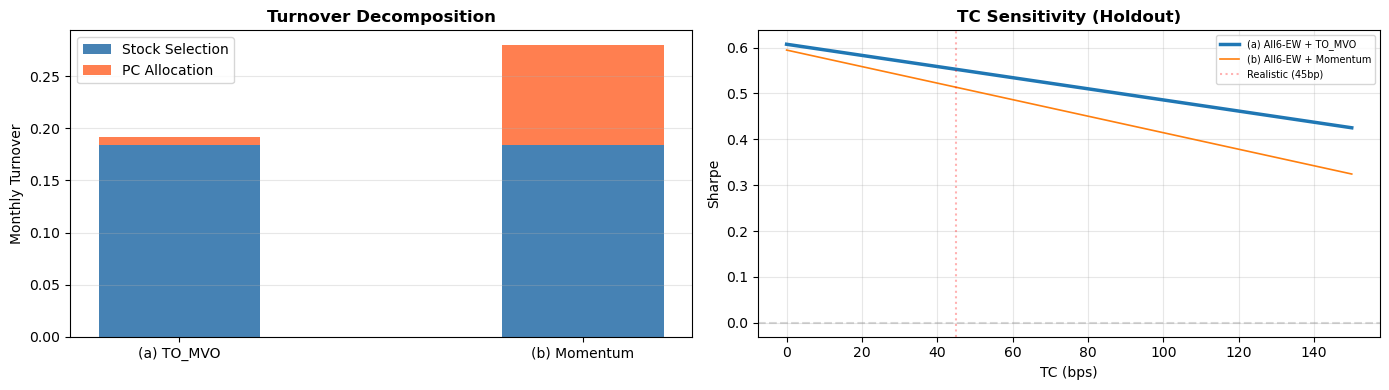

In [2]:
print('TURNOVER DECOMPOSITION')
print('='*70)
print(f'  {"":30s} {"Stock TO":>10s} {"PC TO":>10s} {"Total TO":>10s} {"Ann Turns":>10s}')
print(f'  {"-"*70}')
for name, info in STRATS.items():
    sto = stock_to
    pto = pc_to.get('TO_MVO' if 'TO_MVO' in name else 'Momentum', 0)
    tot = info['to']
    print(f'  {name:30s} {sto:10.3f} {pto:10.3f} {tot:10.3f} {tot*12:10.1f}x')

print(f'\n  Stock-level TO is identical (same All6-EW factor portfolio).')
print(f'  TO_MVO\'s lower PC turnover ({pc_to.get("TO_MVO",0):.3f} vs {pc_to.get("Momentum",0):.3f}) is the built-in turnover penalty.')

# TC cost at different levels
print(f'\nMONTHLY TC DRAG (return drag per month)')
print(f'  {"":30s} {"@20bp":>8s} {"@30bp":>8s} {"@45bp":>8s} {"@60bp":>8s} {"@100bp":>8s}')
for name, info in STRATS.items():
    vals = [info['to'] * bps / 10000 for bps in [20, 30, 45, 60, 100]]
    print(f'  {name:30s}' + ''.join(f' {v*100:7.2f}%' for v in vals))

# Time-series turnover if available
try:
    to_ts = pd.read_csv(f'{OUTPUT_DIR}/csv/nb11_turnover_decomposition.csv', index_col=0, parse_dates=True)
    holdout_to = to_ts[to_ts.index >= HOLD_START]
    if len(holdout_to) > 0 and 'stock_turnover' in holdout_to.columns:
        print(f'\nHOLDOUT TURNOVER TIME-SERIES (from NB11)')
        for col in ['stock_turnover','alloc_turnover','total_turnover']:
            if col in holdout_to.columns:
                s = holdout_to[col].dropna()
                print(f'  {col:25s}: mean={s.mean():.3f}, median={s.median():.3f}, max={s.max():.3f}')
except Exception:
    pass

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
labels = ['(a) TO_MVO', '(b) Momentum']
stock_vals = [stock_to, stock_to]
pc_vals = [pc_to.get('TO_MVO', 0), pc_to.get('Momentum', 0)]
x = np.arange(2)
ax.bar(x, stock_vals, 0.4, label='Stock Selection', color='steelblue')
ax.bar(x, pc_vals, 0.4, bottom=stock_vals, label='PC Allocation', color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Monthly Turnover'); ax.set_title('Turnover Decomposition', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
tc_levels = list(range(0, 151, 5))
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    sharpes = [ann_sharpe(s - info['to']*(t/10000)) for t in tc_levels]
    lw = 2.5 if 'TO_MVO' in name else 1.2
    ax.plot(tc_levels, sharpes, linewidth=lw, label=name)
ax.axvline(x=45, color='red', alpha=0.3, linestyle=':', label='Realistic (45bp)')
ax.axhline(y=0, color='gray', alpha=0.3, linestyle='--')
ax.set_xlabel('TC (bps)'); ax.set_ylabel('Sharpe')
ax.set_title('TC Sensitivity (Holdout)', fontweight='bold')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb07_turnover.pdf', bbox_inches='tight')
plt.show()

## 3. Performance Summary

In [3]:
rows = []
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    s_net = s - info['tc']
    rows.append({
        'Strategy': name,
        'Ann Ret (gross)': ann_ret(s), 'Ann Ret (net)': ann_ret(s_net),
        'Ann Vol': ann_vol(s),
        'Sharpe (gross)': ann_sharpe(s), 'Sharpe (net)': ann_sharpe(s_net),
        'Max DD': max_dd(s), 'Max DD (net)': max_dd(s_net),
        '% Pos': (s>0).mean(), 'N': len(s),
    })

for bench_name, bench_ret in [('EEM (total-return)', eem_ret), ('MSCI EM (price)', msci_ret)]:
    b = bench_ret.reindex(holdout_eem).dropna()
    rows.append({
        'Strategy': bench_name,
        'Ann Ret (gross)': ann_ret(b), 'Ann Ret (net)': ann_ret(b),
        'Ann Vol': ann_vol(b),
        'Sharpe (gross)': ann_sharpe(b), 'Sharpe (net)': ann_sharpe(b),
        'Max DD': max_dd(b), 'Max DD (net)': max_dd(b),
        '% Pos': (b>0).mean(), 'N': len(b),
    })

perf = pd.DataFrame(rows)
print('LONG-ONLY HOLDOUT PERFORMANCE (2019-01 to 2024-09)')
print('=' * 120)
print(perf.to_string(index=False, float_format=lambda x: f'{x:.3f}' if abs(x)<2 else f'{x:.1%}'))

a = perf[perf.Strategy.str.contains('TO_MVO')].iloc[0]
b = perf[perf.Strategy.str.contains('Momentum')].iloc[0]
eem = perf[perf.Strategy.str.contains('EEM')].iloc[0]
print(f'\n(a) TO_MVO vs (b) Momentum: +{a["Sharpe (net)"]-b["Sharpe (net)"]:.3f} net Sharpe')
print(f'(a) TO_MVO vs EEM:          +{a["Sharpe (net)"]-eem["Sharpe (gross)"]:.3f} Sharpe')
print(f'(a) TO_MVO alpha vs EEM:    +{a["Ann Ret (net)"]-eem["Ann Ret (gross)"]:.2%} p.a.')

LONG-ONLY HOLDOUT PERFORMANCE (2019-01 to 2024-09)
              Strategy  Ann Ret (gross)  Ann Ret (net)  Ann Vol  Sharpe (gross)  Sharpe (net)  Max DD  Max DD (net)  % Pos  N
  (a) All6-EW + TO_MVO            0.115          0.105    0.189           0.607         0.552  -0.274        -0.285  0.609 69
(b) All6-EW + Momentum            0.111          0.096    0.187           0.594         0.513  -0.286        -0.309  0.594 69
    EEM (total-return)            0.066          0.066    0.185           0.356         0.356  -0.367        -0.367  0.565 69
       MSCI EM (price)            0.050          0.050    0.183           0.274         0.274  -0.384        -0.384  0.565 69

(a) TO_MVO vs (b) Momentum: +0.039 net Sharpe
(a) TO_MVO vs EEM:          +0.197 Sharpe
(a) TO_MVO alpha vs EEM:    +3.89% p.a.


## 4. Cumulative Returns & Drawdown

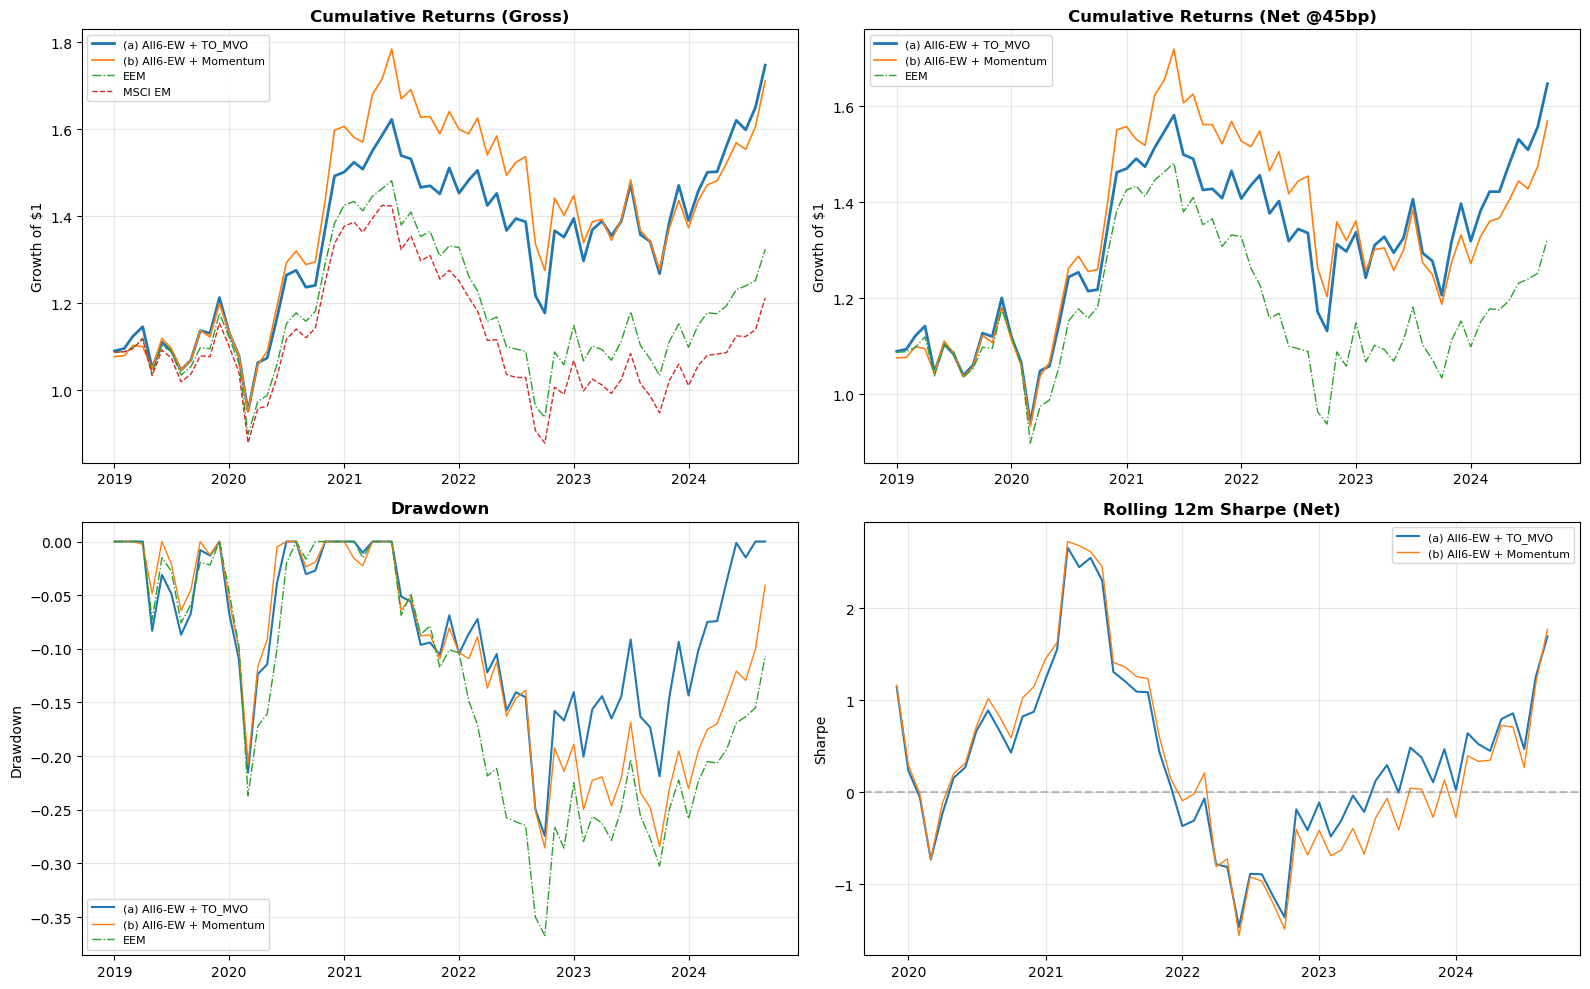

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0,0]
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    ax.plot((1+s).cumprod().index, (1+s).cumprod().values,
            linewidth=2 if 'TO_MVO' in name else 1.2, label=name)
for bn, br in [('EEM', eem_ret), ('MSCI EM', msci_ret)]:
    b = br.reindex(holdout_eem).dropna()
    ls = '--' if bn == 'MSCI EM' else '-.'
    ax.plot((1+b).cumprod().index, (1+b).cumprod().values, ls, linewidth=1, label=bn)
ax.set_title('Cumulative Returns (Gross)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

ax = axes[0,1]
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna() - info['tc']
    ax.plot((1+s).cumprod().index, (1+s).cumprod().values,
            linewidth=2 if 'TO_MVO' in name else 1.2, label=name)
b = eem_ret.reindex(holdout_eem).dropna()
ax.plot((1+b).cumprod().index, (1+b).cumprod().values, '-.', linewidth=1, label='EEM')
ax.set_title(f'Cumulative Returns (Net @{REALISTIC_TC_BPS:.0f}bp)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

ax = axes[1,0]
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    cum = (1+s).cumprod(); dd = cum/cum.cummax()-1
    ax.plot(dd.index, dd.values, linewidth=1.5 if 'TO_MVO' in name else 1, label=name)
b = eem_ret.reindex(holdout_eem).dropna()
cum_b = (1+b).cumprod(); dd_b = cum_b/cum_b.cummax()-1
ax.plot(dd_b.index, dd_b.values, '-.', linewidth=1, label='EEM')
ax.set_title('Drawdown', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Drawdown')

ax = axes[1,1]
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna() - info['tc']
    roll = s.rolling(12).apply(lambda x: x.mean()*12/(x.std()*np.sqrt(12)) if x.std()>0 else 0)
    ax.plot(roll.index, roll.values, linewidth=1.5 if 'TO_MVO' in name else 1, label=name)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Rolling 12m Sharpe (Net)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Sharpe')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb07_holdout_performance.pdf', bbox_inches='tight')
plt.show()

## 5. TC Sensitivity & Break-Even

In [5]:
tc_levels = [0, 10, 20, 30, 45, 50, 75, 100, 150]
tc_sens = {}
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    tc_sens[name] = {f'{t}bp': ann_sharpe(s - info['to']*(t/10_000)) for t in tc_levels}

tc_df = pd.DataFrame(tc_sens).T
print('TC SENSITIVITY: Holdout Sharpe at Various Cost Levels')
print('='*100)
print(tc_df.to_string(float_format='%.3f'))

print('\nBreak-Even TC (Sharpe=0):')
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    if info['to'] > 0 and s.mean() > 0:
        be = s.mean() / info['to'] * 10000
        print(f'  {name:30s}: {be:.0f} bps')

print('\nTO_MVO advantage widens at higher TC because its turnover is 31% lower than Momentum.')

TC SENSITIVITY: Holdout Sharpe at Various Cost Levels
                         0bp  10bp  20bp  30bp  45bp  50bp  75bp  100bp  150bp
(a) All6-EW + TO_MVO   0.607 0.595 0.583 0.571 0.552 0.546 0.516  0.486  0.425
(b) All6-EW + Momentum 0.594 0.576 0.558 0.540 0.513 0.504 0.459  0.414  0.324

Break-Even TC (Sharpe=0):
  (a) All6-EW + TO_MVO          : 500 bps
  (b) All6-EW + Momentum        : 330 bps

TO_MVO advantage widens at higher TC because its turnover is 31% lower than Momentum.


## 6. Annual Returns

ANNUAL RETURNS (Net @45bp)
      (a) All6-EW + TO_MVO  (b) All6-EW + Momentum    EEM
ym                                                       
2019                 20.0%                   18.1%  17.7%
2020                 21.8%                   31.3%  17.6%
2021                  0.2%                    1.1%  -3.7%
2022                -11.5%                  -15.8% -20.5%
2023                  7.7%                    0.9%   8.9%
2024                 17.9%                   17.8%  14.9%


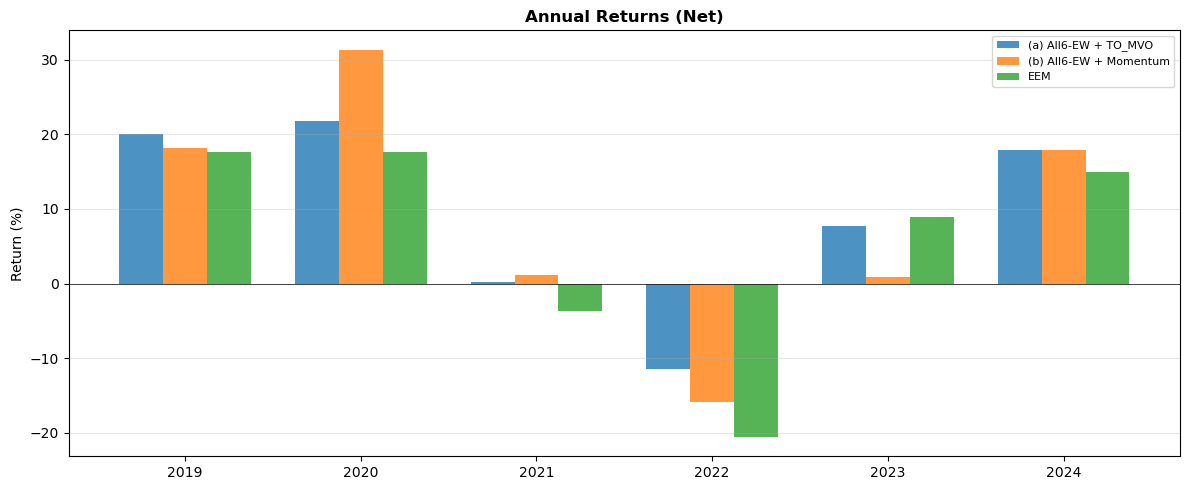

In [6]:
annual = pd.DataFrame()
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna() - info['tc']
    annual[name] = (1+s).groupby(s.index.year).prod() - 1

b = eem_ret.reindex(holdout_eem).dropna()
annual['EEM'] = (1+b).groupby(b.index.year).prod() - 1

print('ANNUAL RETURNS (Net @45bp)')
print('='*80)
print(annual.to_string(float_format=lambda x: f'{x:.1%}'))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(annual))
w = 0.25
for i, col in enumerate(annual.columns):
    ax.bar(x + i*w, annual[col]*100, w, label=col, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels(annual.index)
ax.set_ylabel('Return (%)'); ax.set_title('Annual Returns (Net)', fontweight='bold')
ax.legend(fontsize=8); ax.axhline(y=0, color='k', lw=0.5); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb07_annual_returns.pdf', bbox_inches='tight')
plt.show()

## 7. Information Ratio vs EEM

In [7]:
print('INFORMATION RATIO vs EEM (Holdout)')
print('='*70)
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna() - info['tc']
    b = eem_ret.reindex(s.index).dropna()
    aligned = pd.concat([s.rename('strat'), b.rename('bench')], axis=1).dropna()
    excess = aligned['strat'] - aligned['bench']
    ir = excess.mean()*12 / (excess.std()*np.sqrt(12))
    te = excess.std()*np.sqrt(12)
    print(f'  {name:30s}: IR={ir:.3f}, Active Ret={excess.mean()*12:.2%}, TE={te:.2%}')

perf.to_csv(f'{OUTPUT_DIR}/csv/nb07_holdout_summary.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR}/csv/nb07_holdout_summary.csv')

INFORMATION RATIO vs EEM (Holdout)
  (a) All6-EW + TO_MVO          : IR=0.598, Active Ret=3.89%, TE=6.51%
  (b) All6-EW + Momentum        : IR=0.465, Active Ret=3.00%, TE=6.47%



Saved to ../output/csv/nb07_holdout_summary.csv


## TC Sensitivity and Return Distribution


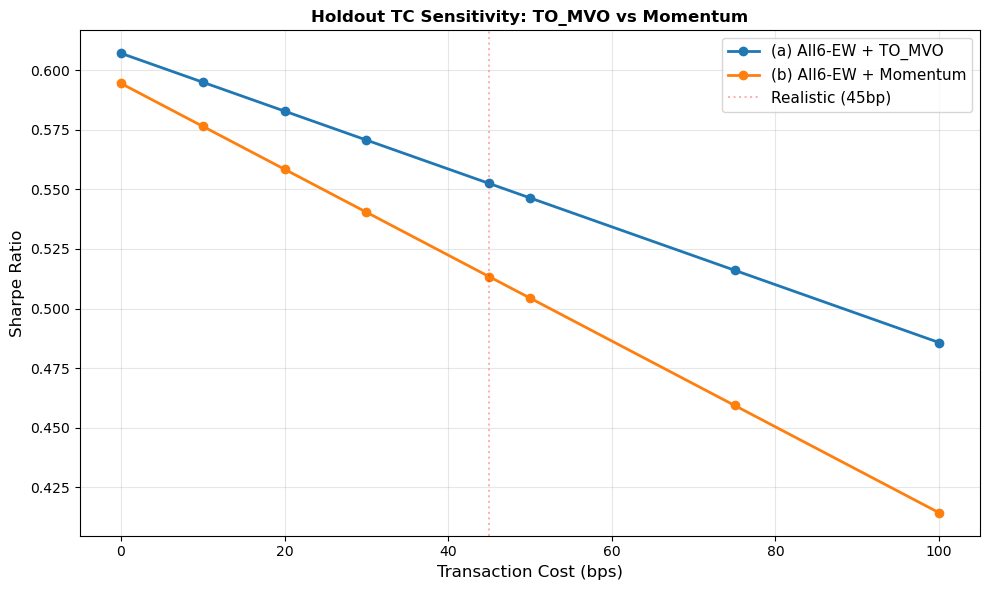

In [8]:
# TC sensitivity in holdout (using proper strategy variables)
tc_levels_extra = [0, 10, 20, 30, 45, 50, 75, 100]

fig, ax = plt.subplots(figsize=(10, 6))
for name, info in STRATS.items():
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    sharpes = [ann_sharpe(s - info['to']*t/10000) for t in tc_levels_extra]
    ax.plot(tc_levels_extra, sharpes, 'o-', lw=2, label=name)
ax.set_xlabel('Transaction Cost (bps)', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Holdout TC Sensitivity: TO_MVO vs Momentum', fontweight='bold')
ax.axvline(x=45, color='red', alpha=0.3, ls=':', label='Realistic (45bp)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb07_tc_sensitivity.pdf', bbox_inches='tight')
plt.show()


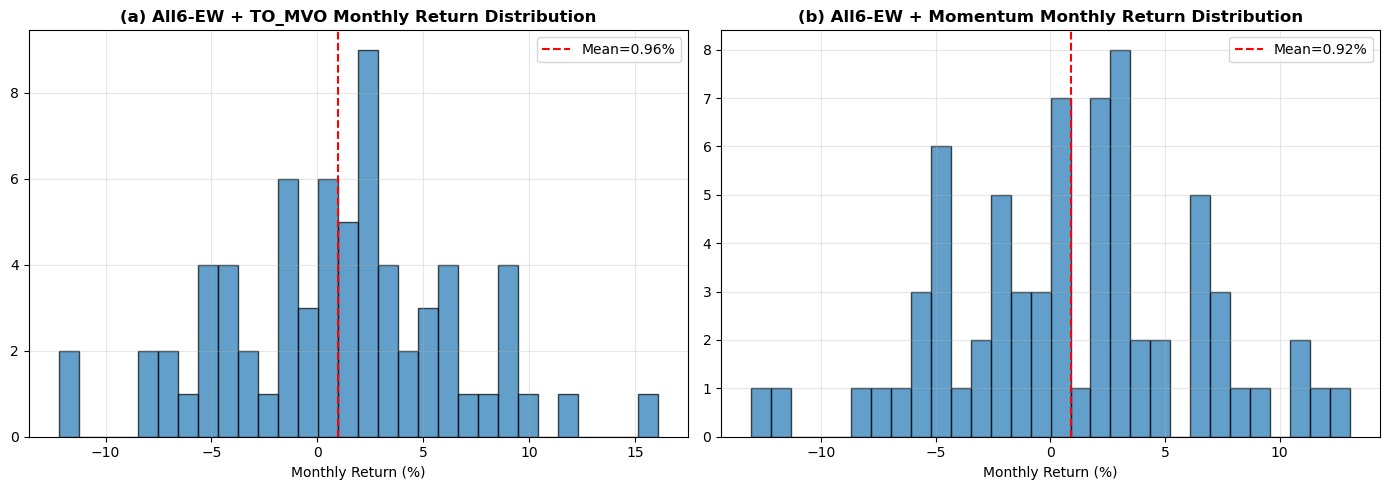

In [9]:
# Return distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, info) in zip(axes, STRATS.items()):
    s = pc_ret.loc[holdout_eem, info['col']].dropna()
    ax.hist(s*100, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(s.mean()*100, color='red', ls='--', label=f'Mean={s.mean()*100:.2f}%')
    ax.set_title(f'{name} Monthly Return Distribution', fontweight='bold')
    ax.set_xlabel('Monthly Return (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb07_return_distribution.pdf', bbox_inches='tight')
plt.show()
